# Crop Level Analysis
---
## Objective
The goal is to analyze crops at both individual and category levels, evaluate their contribution to total production, and examine whether crop rankings are consistent when comparing cultivated area and production output.

In [ ]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../data/clean/agristats_clean.csv")
df.head()

,crop,state,season,year,area,production,yield,area_mha,production_mt,data_quality_flag,crop_category
0,Rice,Andaman And Nicobar Islands,Kharif,2020-21,6256.0,13344.05,2133.0,0.006256,0.013344,GOOD,food_grains
1,Rice,Andhra Pradesh,Kharif,2020-21,1496000.0,4211240.00,2815.0,1.496000,4.211240,GOOD,food_grains
2,Rice,Andhra Pradesh,Rabi,2020-21,827500.0,3671617.50,4437.0,0.827500,3.671617,GOOD,food_grains
3,Rice,Arunachal Pradesh,Kharif,2020-21,133270.0,246416.23,1849.0,0.133270,0.246416,GOOD,food_grains
4,Rice,Arunachal Pradesh,Rabi,2020-21,495.0,663.30,1340.0,0.000495,0.000663,GOOD,food_grains


In [ ]:
# df = df[df["data_quality_flag"] != "INSUFFICIENT"].drop(columns=['area', 'production', 'data_quality_flag'])
df = (
    df[df["data_quality_flag"] != "INSUFFICIENT"]
    .drop(columns=['area', 'production', 'data_quality_flag'])
    .reset_index(drop=True)
)

## *1. Crop Production Landscape*

In [ ]:
# crop summary by production
crop_summary = (
    df.groupby('crop', as_index=False)
      .agg({
          'production_mt': 'sum',
          'area_mha': 'sum',
      })
      .assign(
          Yield=lambda x: np.where(
              x['area_mha'] == 0,
              0,
              x['production_mt'] / x['area_mha']
          )
      )
      .sort_values(by='production_mt', ascending=False) 
).reset_index(drop=True)

In [ ]:
# Note: Share calculated using production volume. 
# Results will vary if area is used as the metric.

total_production = crop_summary["production_mt"].sum()

crop_summary["share_%"] = (crop_summary["production_mt"]/ total_production) * 100
crop_summary["cumulative_share_%"] = (crop_summary["production_mt"].cumsum() / total_production) * 100


In [ ]:
crop_summary.head(10)

,crop,production_mt,area_mha,Yield,share_%,cumulative_share_%
0,Sugarcane,2243.126425,27.101483,82.767663,36.222014,36.222014
1,Cereals,1517.323062,518.177059,2.928194,24.501739,60.723753
2,Rice,677.603730,238.974283,2.835467,10.941948,71.665700
3,Wheat,559.119122,157.621664,3.547223,9.028658,80.694358
4,Nutri Cereals,368.105768,186.403001,1.974785,5.944173,86.638531
5,Maize,184.535342,53.926210,3.421997,2.979877,89.618409
6,Cotton,162.272329,62.755473,2.585788,2.620374,92.238783
7,Soybean,68.912262,64.355798,1.070801,1.112795,93.351578
8,Rapeseed & Mustard,60.742543,41.382734,1.467823,0.980871,94.332449
9,Gram,59.875350,49.916484,1.199511,0.966867,95.299317


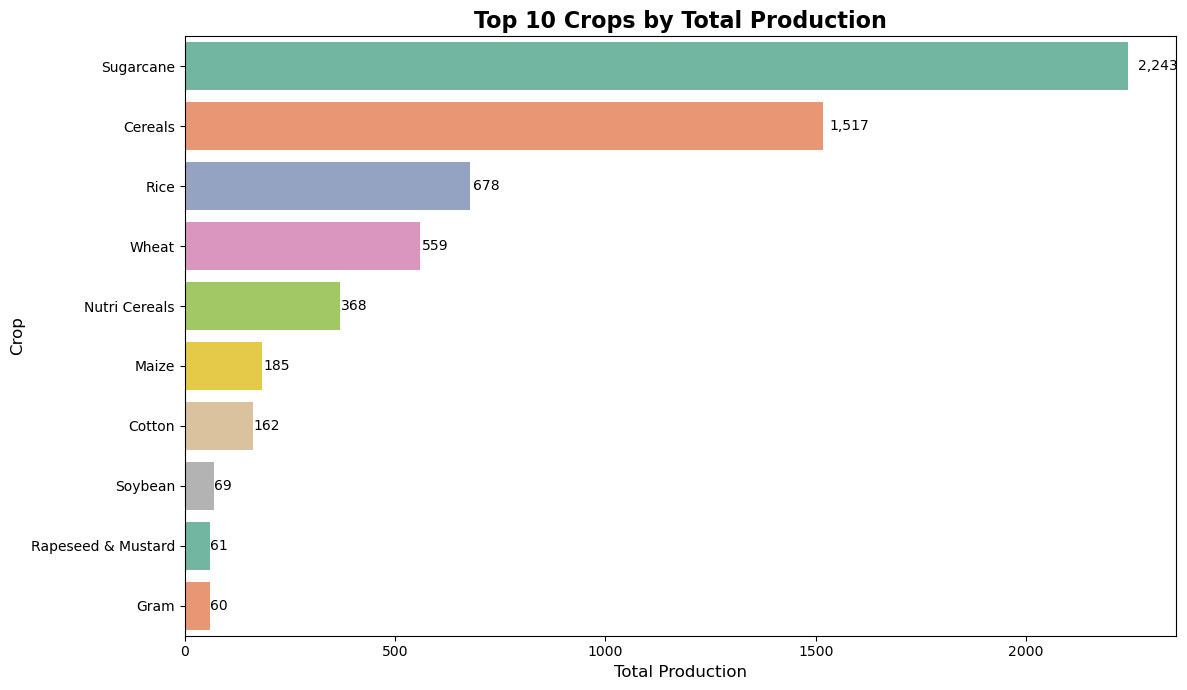

In [ ]:
top10 = crop_summary.head(10)

plt.figure(figsize=(12, 7))

barplot = sns.barplot(
    data=top10,
    x='production_mt',
    y='crop',
    hue = 'crop',
    palette='Set2'
)

for i, v in enumerate(top10['production_mt']):
    # Added a small offset (v * 1.01) to place text slightly to the right of the bar
    barplot.text(v * 1.01, i, f"{v:,.0f}", va='center', fontsize=10, color='black')

# Titles and labels
plt.title('Top 10 Crops by Total Production', fontsize=16, weight='bold')
plt.xlabel('Total Production', fontsize=12)
plt.ylabel('Crop', fontsize=12)

plt.tight_layout()
plt.show()

***Insights*** :
- A small number of crops dominate total production.
- Sugarcane alone contributes ~36%, making it the single largest contributor.
- The top 4 crops (Sugarcane, Cereals, Rice, Wheat) contribute ~80% of total production.
- This indicates a highly concentrated agricultural output, where national production depends on a few key crops.

### *1.1 Pareto Analysis of Crop Production (80/20 Rule)*

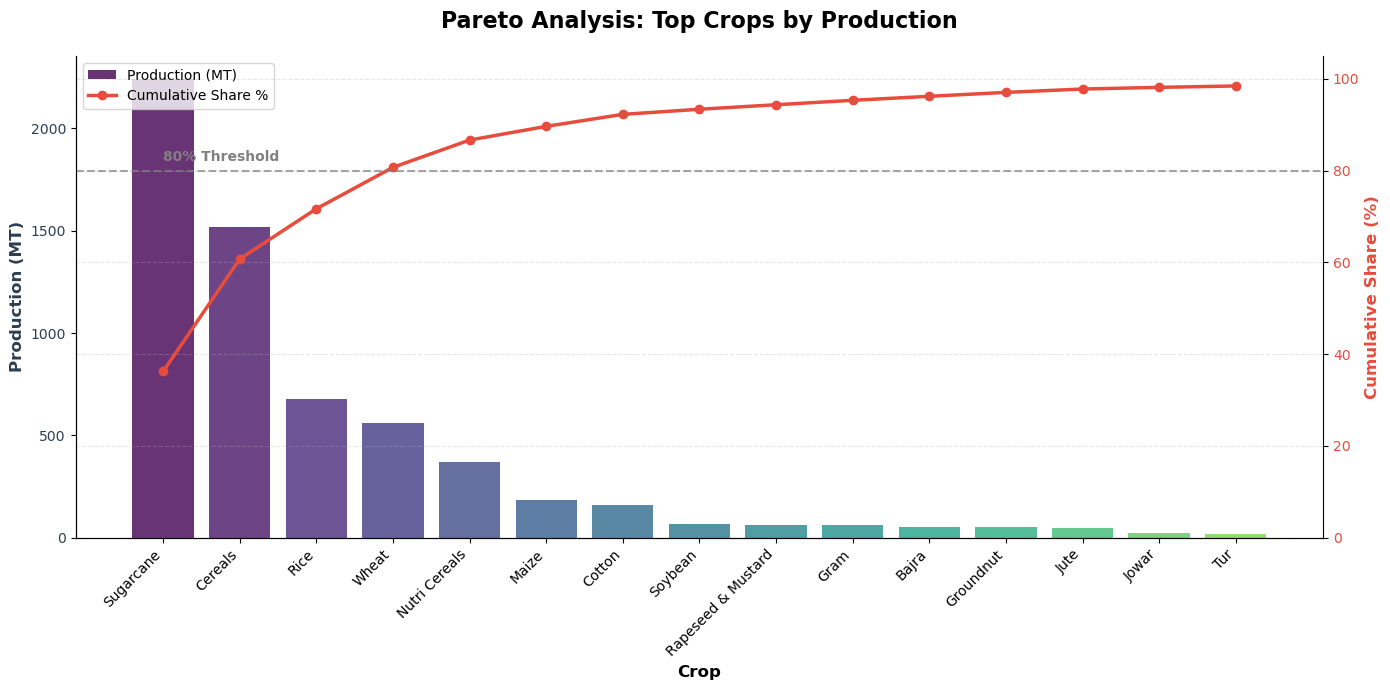

In [ ]:
# 1. Define data clearly
top_crops = crop_summary.head(15)
crops = top_crops["crop"]
production = top_crops["production_mt"]
cum_share = top_crops["cumulative_share_%"]

# 2. Create Figure
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- LEFT AXIS (Production Bars) ---
colors = plt.cm.viridis(np.linspace(0, 0.8, len(crops)))
bars = ax1.bar(crops, production, color=colors, alpha=0.8, label='Production (MT)')

ax1.set_xlabel("Crop", fontsize=12, fontweight='bold')
ax1.set_ylabel("Production (MT)", fontsize=12, fontweight='bold', color='#2c3e50')
ax1.tick_params(axis='y', labelcolor='#2c3e50')

# --- RIGHT AXIS (Cumulative Share Line) ---
ax2 = ax1.twinx()

# Plot the line with a distinct color and markers
line, = ax2.plot(crops, cum_share, color='#e74c3c', marker='o', linewidth=2.5, markersize=6, label='Cumulative Share %')

# 80% Reference Line
ax2.axhline(80, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)
ax2.text(0, 82, "80% Threshold", color="gray", fontsize=10, fontweight='bold')

ax2.set_ylabel("Cumulative Share (%)", fontsize=12, fontweight='bold', color='#e74c3c')
ax2.set_ylim(0, 105) # Give a little breathing room at the top
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# --- FORMATTING ---
# Rotate X labels properly
ax1.set_xticks(range(len(crops)))
ax1.set_xticklabels(crops, rotation=45, ha='right')

# Add gridlines for the secondary axis (makes reading % easier)
ax2.grid(True, linestyle='--', alpha=0.3, axis='y')
ax1.grid(False) # Turn off grid for bars to avoid clutter

# Remove chart borders (spines) for a cleaner look
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# --- LEGEND ---
# Combine legends from both axes
lines = [bars, line]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title("Pareto Analysis: Top Crops by Production", fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

***Insight***:
- The Pareto curve shows that ~20% of crops contribute ~80% of production.
- After the top few crops, the marginal contribution of additional crops drops sharply.

### *1.2 Area vs Production (Scale vs Output Efficiency)*

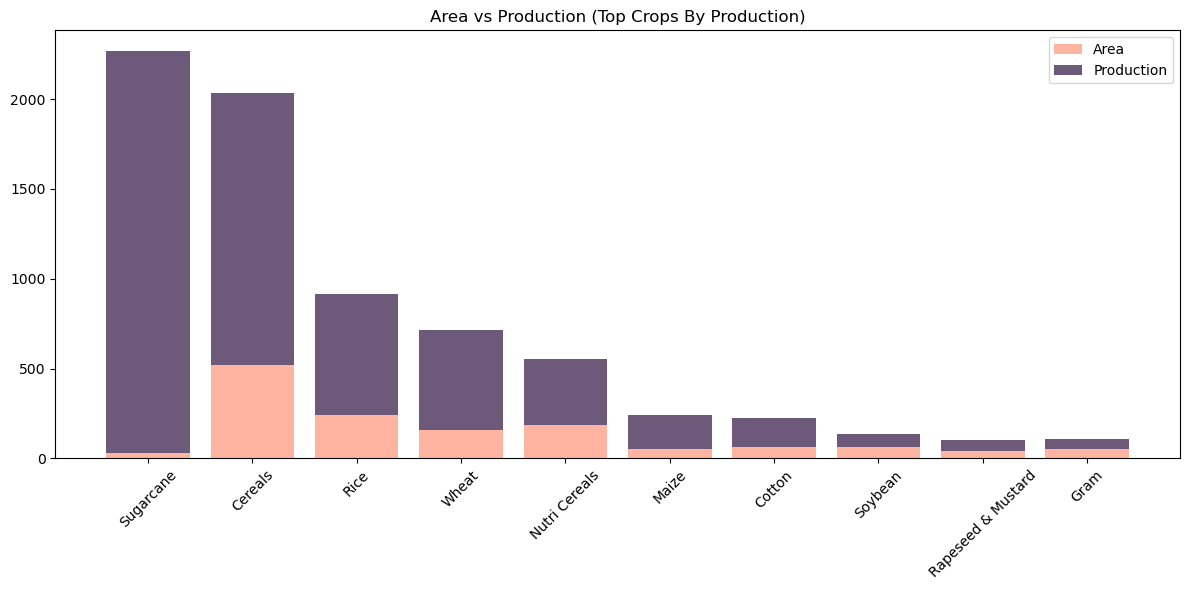

In [ ]:
top_combined_production = crop_summary.head(10)
x = range(len(top_combined_production))

plt.figure(figsize=(12,6))

# A muted earthy brown for Area
plt.bar(x, top_combined_production["area_mha"], color="#FFB4A2", label="Area")
# A vibrant growth green for Production
plt.bar(x, top_combined_production["production_mt"], bottom=top_combined_production["area_mha"], color="#6D597A", label="Production")

plt.xticks(x, top_combined_production["crop"], rotation=45)
plt.title("Area vs Production (Top Crops By Production)")
plt.legend()
plt.tight_layout()
plt.show()

***Insight***:
- Some crops generate high production despite relatively low area (e.g., Sugarcane).
- Others occupy large land area but contribute less proportionally.

## *2. Land Utilization Pattern*

In [ ]:
crop_area = crop_summary.sort_values(by= "area_mha", ascending=False).reset_index(drop=True)

# calculate share and cumilative share
total_area = crop_area["area_mha"].sum()
crop_area["share_%"] = (crop_area["area_mha"] / total_area) * 100
crop_area["cumulative_share_%"] = (crop_area["area_mha"].cumsum() / total_area) * 100

crop_area

,crop,production_mt,area_mha,Yield,share_%,cumulative_share_%
0,Cereals,1517.323062,518.177059,2.928194,31.947441,31.947441
1,Rice,677.603730,238.974283,2.835467,14.733606,46.681047
2,Nutri Cereals,368.105768,186.403001,1.974785,11.492402,58.173449
3,Wheat,559.119122,157.621664,3.547223,9.717931,67.891379
4,Soybean,68.912262,64.355798,1.070801,3.967762,71.859141
5,Cotton,162.272329,62.755473,2.585788,3.869096,75.728237
6,Maize,184.535342,53.926210,3.421997,3.324741,79.052978
7,Gram,59.875350,49.916484,1.199511,3.077527,82.130505
8,Rapeseed & Mustard,60.742543,41.382734,1.467823,2.551391,84.681896
9,Bajra,53.995865,36.797199,1.467391,2.268677,86.950573


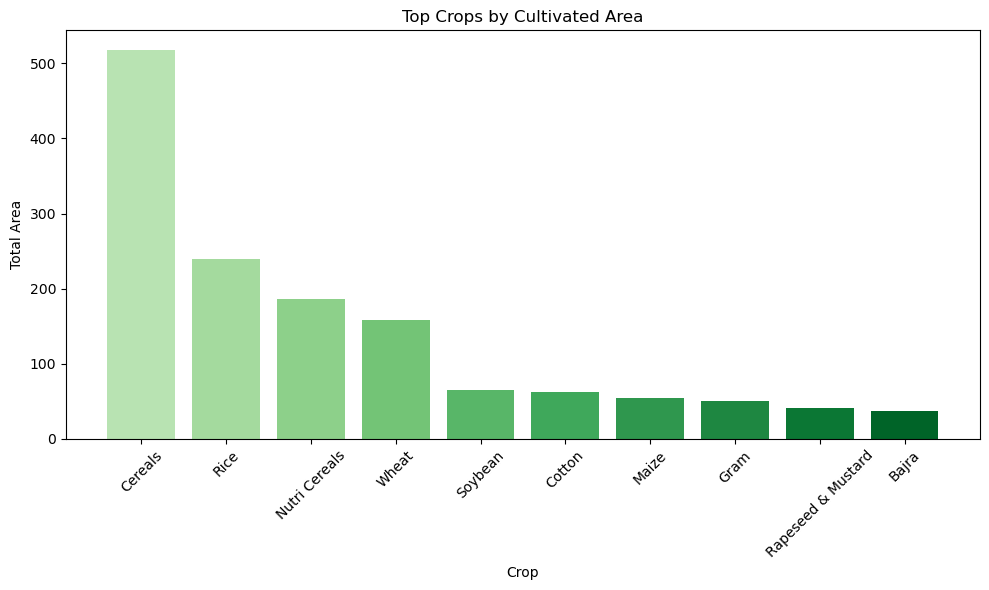

In [ ]:
top_area = crop_area.head(10)   

colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(top_area)))

plt.figure(figsize=(10,6))
plt.bar(top_area["crop"], top_area["area_mha"],color = colors)
plt.xticks(rotation=45)
plt.title("Top Crops by Cultivated Area")
plt.xlabel("Crop")
plt.ylabel("Total Area")
plt.tight_layout()
plt.show()

***Insights***:
- Cereals dominate land usage (~32%), followed by Rice and Nutri Cereals.
- Land distribution is more spread compared to production.

 Key Takeaway
- Agriculture is **land-diversified but output-concentrated**.

### *2.1 Pareto Analysis of Land Usage*

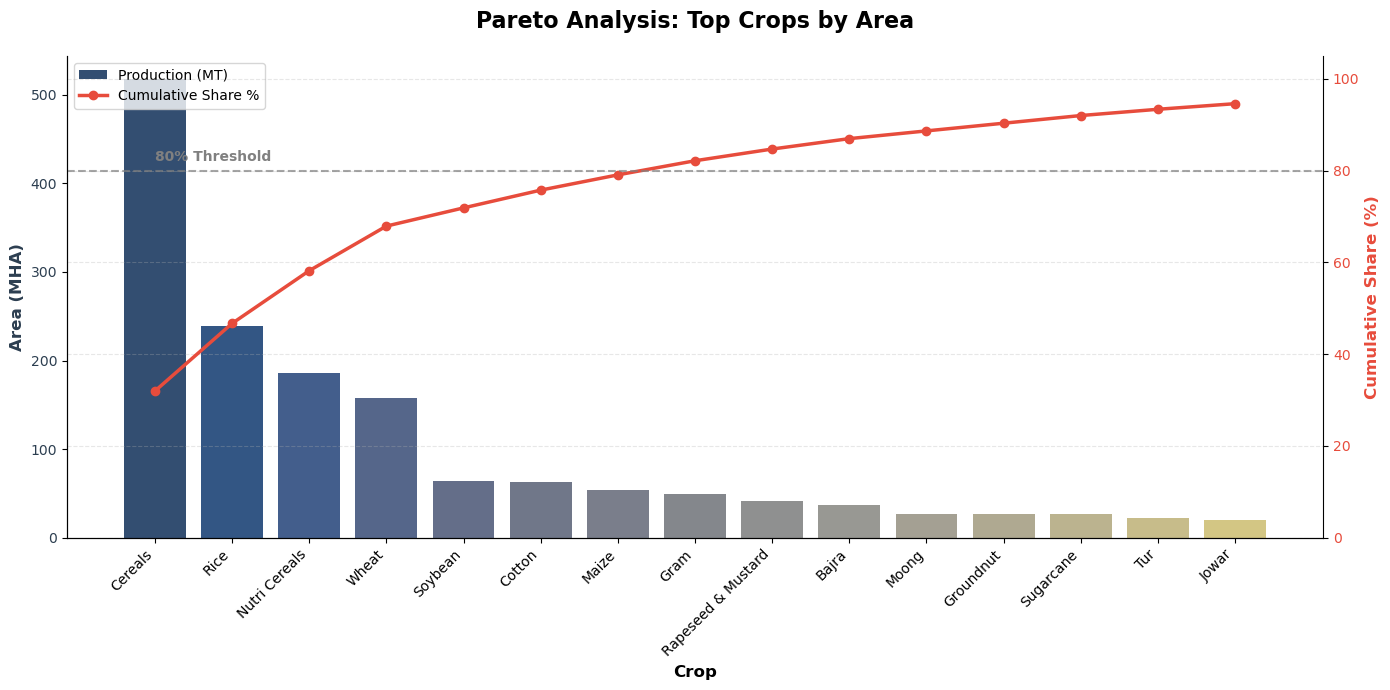

In [ ]:
# Define data 
top_crops = crop_area.head(15)
crops = top_crops["crop"]
area = top_crops["area_mha"]
cum_share = top_crops["cumulative_share_%"]

# Create Figure
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- LEFT AXIS (Production Bars) ---
colors = plt.cm.cividis(np.linspace(0, 0.8, len(crops)))
bars = ax1.bar(crops, area, color=colors, alpha=0.8, label='Production (MT)')

ax1.set_xlabel("Crop", fontsize=12, fontweight='bold')
ax1.set_ylabel("Area (MHA)", fontsize=12, fontweight='bold', color='#2c3e50')
ax1.tick_params(axis='y', labelcolor='#2c3e50')

# --- RIGHT AXIS (Cumulative Share Line) ---
ax2 = ax1.twinx()

# Plot the line with a distinct color and markers
line, = ax2.plot(crops, cum_share, color='#e74c3c', marker='o', linewidth=2.5, markersize=6, label='Cumulative Share %')

# 80% Reference Line
ax2.axhline(80, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)
ax2.text(0, 82, "80% Threshold", color="gray", fontsize=10, fontweight='bold')

ax2.set_ylabel("Cumulative Share (%)", fontsize=12, fontweight='bold', color='#e74c3c')
ax2.set_ylim(0, 105) # Give a little breathing room at the top
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# --- FORMATTING ---
ax1.set_xticks(range(len(crops)))
ax1.set_xticklabels(crops, rotation=45, ha='right')

# Add gridlines for the secondary axis (makes reading % easier)
ax2.grid(True, linestyle='--', alpha=0.3, axis='y')
ax1.grid(False) # Turn off grid for bars to avoid clutter

# Remove chart borders (spines) for a cleaner look
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# --- LEGEND ---
# Combine legends from both axes
lines = [bars, line]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title("Pareto Analysis: Top Crops by Area", fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

***Insight***: <br>
Land usage is less concentrated compared to production.


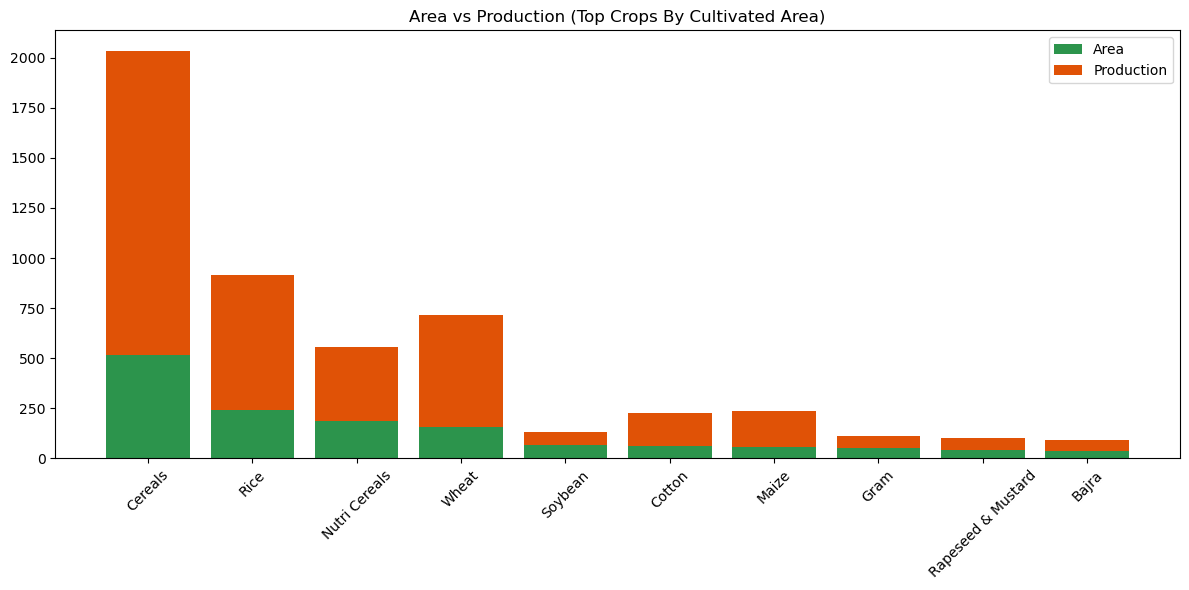

In [ ]:
top_combined_area = crop_area.head(10)
x = range(len(top_combined_area))

plt.figure(figsize=(12,6))

# Use distinct colors for area and production
plt.bar(x, top_combined_area["area_mha"], label="Area", color=sns.color_palette("Greens")[4])
plt.bar(x, top_combined_area["production_mt"], bottom=top_combined_area["area_mha"], label="Production", color=sns.color_palette("Oranges")[4])

plt.xticks(x, top_combined_area["crop"], rotation=45)
plt.title("Area vs Production (Top Crops By Cultivated Area)")
plt.legend()
plt.tight_layout()
plt.show()

## *3. Yield Analysis (Efficiency Comparison Across Crops)*

In [ ]:
crop_yield = crop_summary.sort_values(by="Yield", ascending=False)[["crop","area_mha", "production_mt", "Yield"]].reset_index(drop=True)
crop_yield

,crop,area_mha,production_mt,Yield
0,Sugarcane,27.101483,2243.126425,82.767663
1,Jute,3.012893,45.443973,15.083169
2,Mesta,0.186579,1.944877,10.423877
3,Sannhemp,0.041294,0.173735,4.207282
4,Wheat,157.621664,559.119122,3.547223
5,Maize,53.926210,184.535342,3.421997
6,Barley,2.833015,8.559310,3.021273
7,Cereals,518.177059,1517.323062,2.928194
8,Rice,238.974283,677.603730,2.835467
9,Cotton,62.755473,162.272329,2.585788


***Insight***:
- Sugarcane has extremely high yield (~82) compared to others.
- Crops like pulses and oilseeds show significantly lower yield.


## *4. Yield vs Production Relationship (Scaling vs Efficiency)*

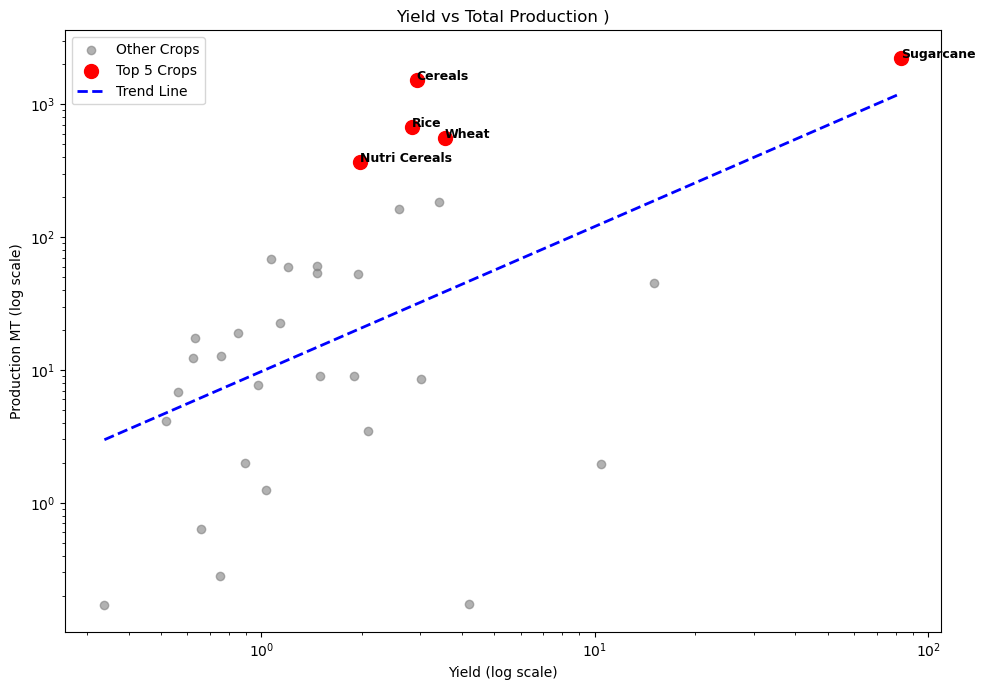

In [ ]:
plt.figure(figsize=(10, 7))

# ---- Identify Top 5 crops ----
top5 = crop_yield.nlargest(5, "production_mt")

# ---- Scatter plot ----
plt.scatter(
    crop_yield["Yield"],
    crop_yield["production_mt"],
    color="gray",
    alpha=0.6,
    label="Other Crops"
)

# Highlight top 5
plt.scatter(
    top5["Yield"],
    top5["production_mt"],
    color="red",
    s=100,
    label="Top 5 Crops"
)

# ---- Log scale ----
plt.xscale("log")
plt.yscale("log")

# ---- Add labels ONLY for top 5 ----
for i in range(len(top5)):
    plt.text(
        top5["Yield"].iloc[i],
        top5["production_mt"].iloc[i],
        top5["crop"].iloc[i],
        fontsize=9,
        weight="bold"
    )

# ---- Trend line (log-log regression) ----
x = np.log10(crop_yield["Yield"])
y = np.log10(crop_yield["production_mt"])

coeffs = np.polyfit(x, y, 1)
trendline = np.poly1d(coeffs)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = trendline(x_line)

plt.plot(
    10**x_line,
    10**y_line,
    color="blue",
    linestyle="--",
    linewidth=2,
    label="Trend Line"
)

# ---- Labels & title ----
plt.xlabel("Yield (log scale)")
plt.ylabel("Production MT (log scale)")
plt.title("Yield vs Total Production )")
plt.legend()

plt.tight_layout()
plt.show()

***Insight***:
- Weak correlation between yield and total production.
- Some crops have high production due to scale (area), not efficiency.


## *5. Quadrant Analysis (Strategic Crop Segmentation)*

In [ ]:
yield_threshold = crop_yield["Yield"].median()
production_threshold = crop_yield["production_mt"].median()

def classify(row):
    if row["Yield"] >= yield_threshold and row["production_mt"] >= production_threshold:
        return "High Yield + High Production"
    elif row["Yield"] >= yield_threshold and row["production_mt"] < production_threshold:
        return "High Yield + Low Production"
    elif row["Yield"] < yield_threshold and row["production_mt"] >= production_threshold:
        return "Low Yield + High Production"
    else:
        return "Low Yield + Low Production"

crop_yield["Quadrant"] = crop_yield.apply(classify, axis=1)

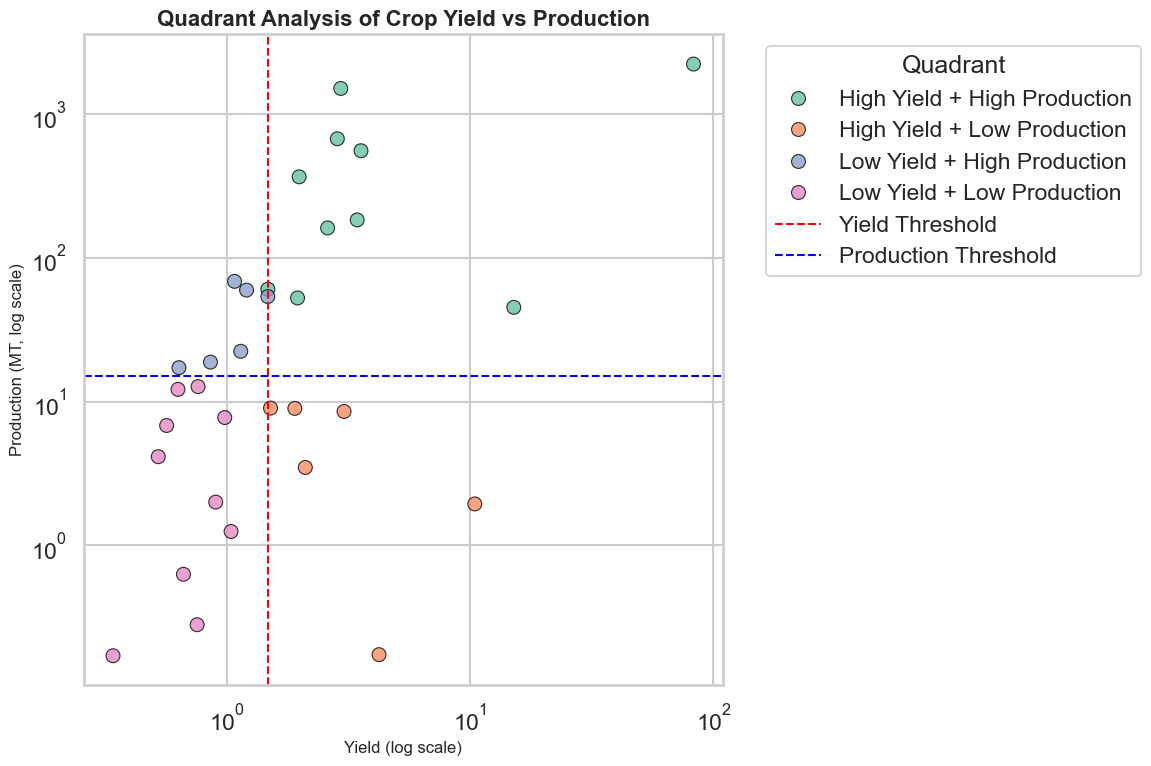

In [ ]:
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=crop_yield,
    x="Yield",
    y="production_mt",
    hue="Quadrant",
    palette="Set2",
    s=100,          # marker size
    edgecolor="black",
    alpha=0.8
)

# Add quadrant lines
plt.axvline(x=yield_threshold, color='red', linestyle='--', linewidth=1.5, label="Yield Threshold")
plt.axhline(y=production_threshold, color='blue', linestyle='--', linewidth=1.5, label="Production Threshold")

# Log scale for better spread
plt.xscale("log")
plt.yscale("log")

# Labels and title
plt.title("Quadrant Analysis of Crop Yield vs Production", fontsize=16, weight='bold')
plt.xlabel("Yield (log scale)", fontsize=12)
plt.ylabel("Production (MT, log scale)", fontsize=12)

# Improve legend
plt.legend(title="Quadrant", bbox_to_anchor=(1.05, 1), loc='upper left')

# Tight layout for spacing
plt.tight_layout()

plt.show()

#### Quadrant Interpretation (Yield vs Production)

This analysis divides crops into four categories based on Yield (efficiency) and Total Production (scale).

1. **High Yield + High Production → Ideal Crops**
   - These crops are both efficient and widely cultivated
   - They contribute significantly to total output
   - Represent the strongest segment of agriculture

   **Interpretation:**
   These are the most balanced and desirable crops. They should be prioritized for continued investment and support.

2. **High Yield + Low Production → Underutilized Crops**
   - These crops have high productivity per hectare
   - But are grown on limited land

   **Interpretation:**
   These crops are highly efficient but under-scaled. Expanding their cultivation could significantly increase overall agricultural output.

3. **Low Yield + High Production → Inefficient but Essential Crops**
   - These crops are widely cultivated
   - But have low productivity

   **Interpretation:**
   These are typically staple crops that dominate land use. Improving their yield through better techniques or technology can have a large impact.

4. **Low Yield + Low Production → Least Impactful Crops**
   - These crops have low efficiency
   - And low contribution to total production

   **Interpretation:**
   They play a minor role in overall agriculture. They are lower priority for optimization or expansion.

## *6. Crop Category Contribution (Macro-Level Analysis)*

In [ ]:
category_summary = (
    df.groupby('crop_category', as_index=False)
      .agg({
          'production_mt': 'sum',
          'area_mha': 'sum',
      }).assign(
          Yield=lambda x: np.where(
              x['area_mha'] == 0,
              0,
              x['production_mt'] / x['area_mha']
          )
      )
      .sort_values(by='production_mt', ascending=False)
)

category_summary["share_%"] = (category_summary["production_mt"]/ total_production) * 100
category_summary["cumulative_share_%"] = (category_summary["production_mt"].cumsum() / total_production) * 100

category_summary

,crop_category,production_mt,area_mha,Yield,share_%,cumulative_share_%
0,food_grains,3402.751893,1222.757119,2.782852,54.947651,54.947651
1,industrial_crops,2456.451227,94.764861,25.921541,39.666784,94.614434
2,oilseeds,204.761294,160.803879,1.273360,3.306486,97.920921
3,pulses,128.751486,143.641489,0.896339,2.079079,100.000000


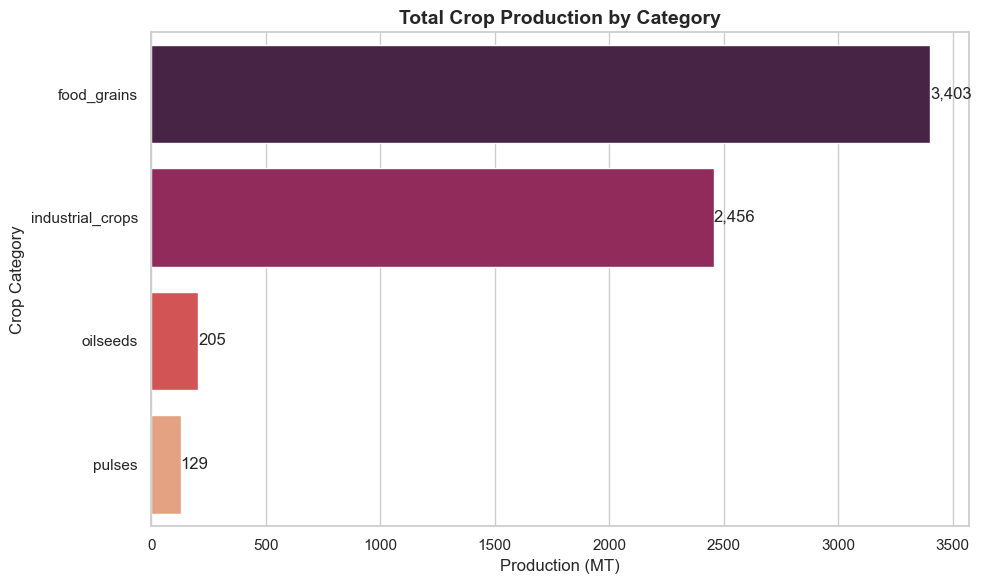

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_summary,
    x='production_mt',
    y='crop_category',
    palette='rocket',
    hue = 'crop_category'
)

# Add labels
for i, v in enumerate(category_summary['production_mt']):
    ax.text(v, i, f"{v:,.0f}", va='center')

plt.title('Total Crop Production by Category', fontsize=14, weight='bold')
plt.xlabel('Production (MT)')
plt.ylabel('Crop Category')

plt.tight_layout()
plt.show()

***Insight***:
- Food grains contribute ~55% of production.
- Industrial crops contribute ~40% despite very low land usage (~6%).

## *7. Land vs Production Share (Efficiency Gap Analysis)*

In [ ]:
cat_data = df.groupby("crop_category").agg({
    "production_mt": "sum",
    "area_mha": "sum"
}).reset_index()

cat_data["avg_yield"] = cat_data["production_mt"] / cat_data["area_mha"]

total_prod = cat_data["production_mt"].sum()
total_area = cat_data["area_mha"].sum()

cat_data["Production_Share (%)"] = (cat_data["production_mt"] / total_prod) * 100
cat_data["Land_Share (%)"] = (cat_data["area_mha"] / total_area) * 100

In [ ]:
cat_data

,crop_category,production_mt,area_mha,avg_yield,Production_Share (%),Land_Share (%)
0,food_grains,3402.751893,1222.757119,2.782852,54.947651,75.387283
1,industrial_crops,2456.451227,94.764861,25.921541,39.666784,5.842587
2,oilseeds,204.761294,160.803879,1.273360,3.306486,9.914126
3,pulses,128.751486,143.641489,0.896339,2.079079,8.856004


In [ ]:
cat_data["Efficiency_Gap"] = cat_data["Production_Share (%)"] - cat_data["Land_Share (%)"]

In [ ]:
cat_data = cat_data.sort_values(by="avg_yield", ascending=False)

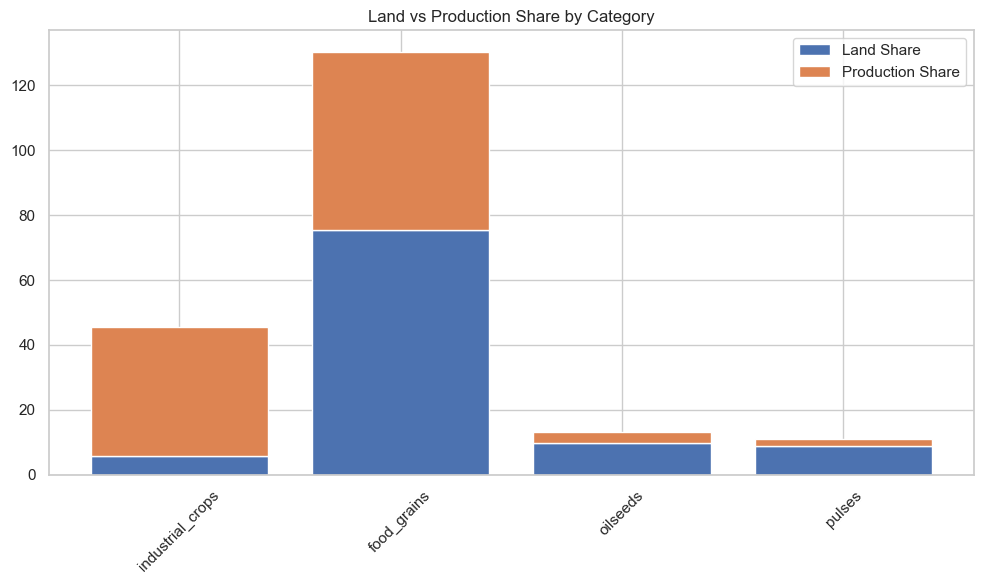

In [ ]:
x = range(len(cat_data))

plt.figure(figsize=(10,6))
plt.bar(x, cat_data["Land_Share (%)"], label="Land Share")
plt.bar(x, cat_data["Production_Share (%)"], bottom=cat_data["Land_Share (%)"], label="Production Share")

plt.xticks(x, cat_data["crop_category"], rotation=45)
plt.title("Land vs Production Share by Category")
plt.legend()
plt.tight_layout()
plt.show()

***Insight***:
- Food grains use ~75% of land but produce only ~55% output → negative efficiency gap
- Industrial crops use ~6% land but produce ~40% output → positive efficiency gap

## *8. Average Yield by Crop Category*

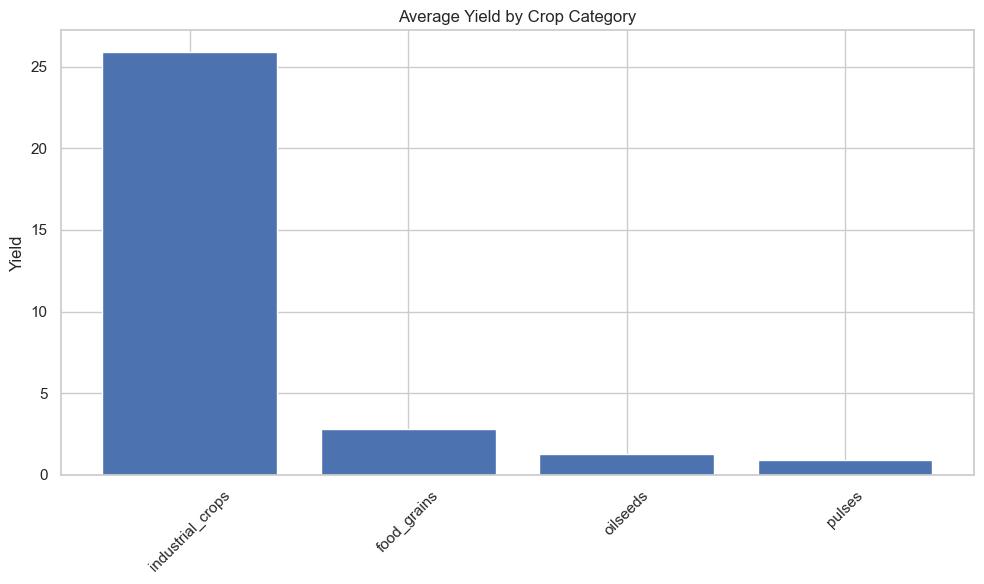

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(cat_data["crop_category"], cat_data["avg_yield"])
plt.xticks(rotation=45)
plt.title("Average Yield by Crop Category")
plt.ylabel("Yield")
plt.tight_layout()
plt.show()

***Insight***:
- Industrial crops have the highest average yield by a large margin.
- Pulses and oilseeds have consistently low yields.


## *9. State level Crop Category Analysis*

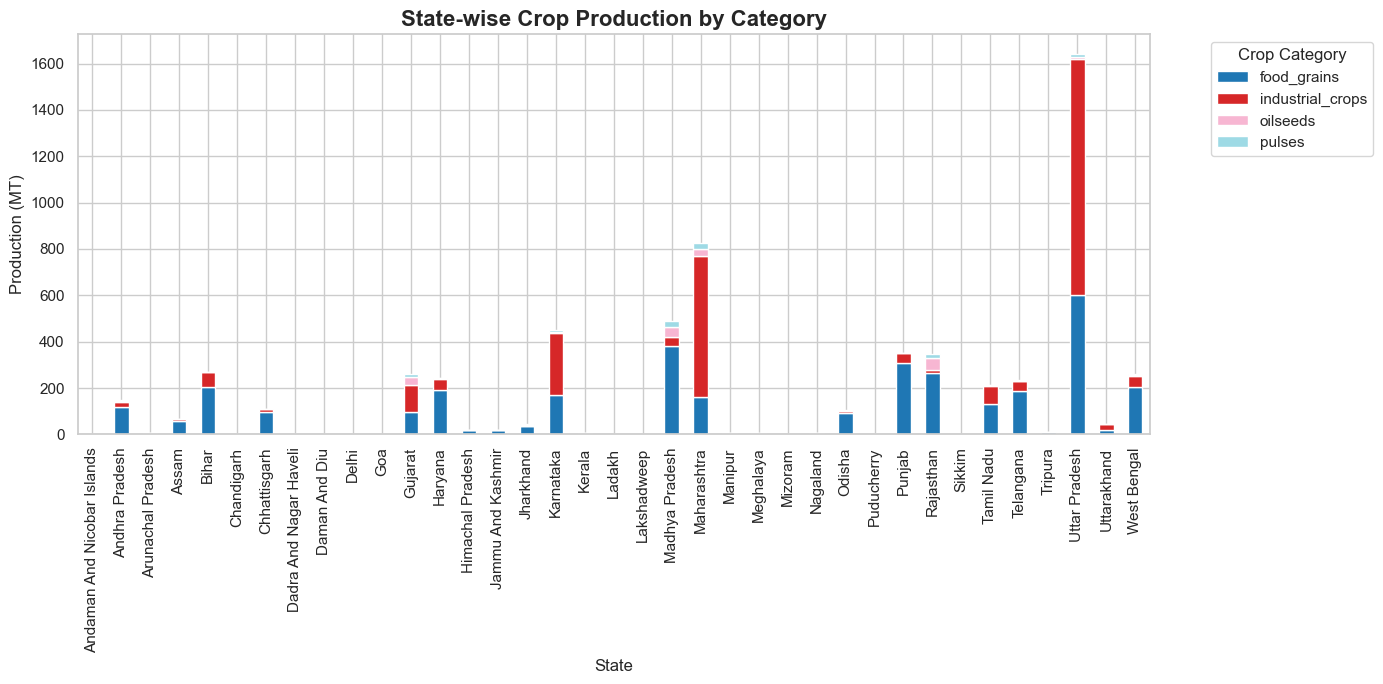

In [ ]:
state_category = (
    df.groupby(['state', 'crop_category'], as_index=False)
      .agg({'production_mt': 'sum'})
)

pivot_table = state_category.pivot(
    index='state',
    columns='crop_category',
    values='production_mt'
).fillna(0)

pivot_table.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='tab20'
)

plt.title('State-wise Crop Production by Category', fontsize=16, weight='bold')
plt.xlabel('State')
plt.ylabel('Production (MT)')
plt.legend(title='Crop Category', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

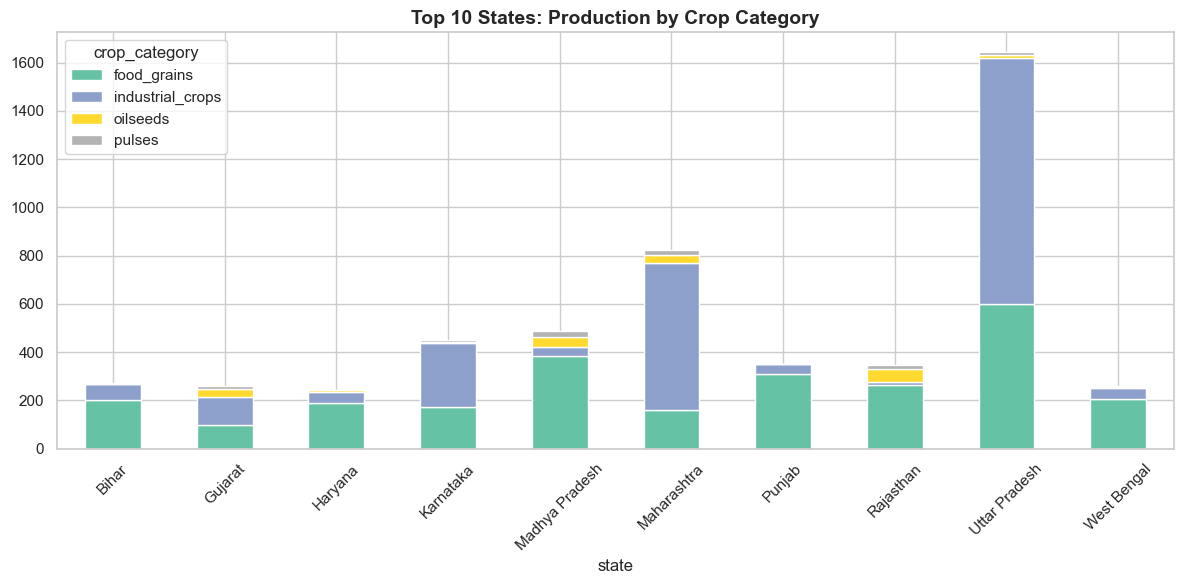

In [ ]:
top_states = (
    state_category.groupby('state')['production_mt']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

filtered = state_category[state_category['state'].isin(top_states)]

pivot_top = filtered.pivot(
    index='state',
    columns='crop_category',
    values='production_mt'
).fillna(0)

pivot_top.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='Set2'
)

plt.title('Top 10 States: Production by Crop Category', fontsize=14, weight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ***State-wise Crop Category Production Heatmap***

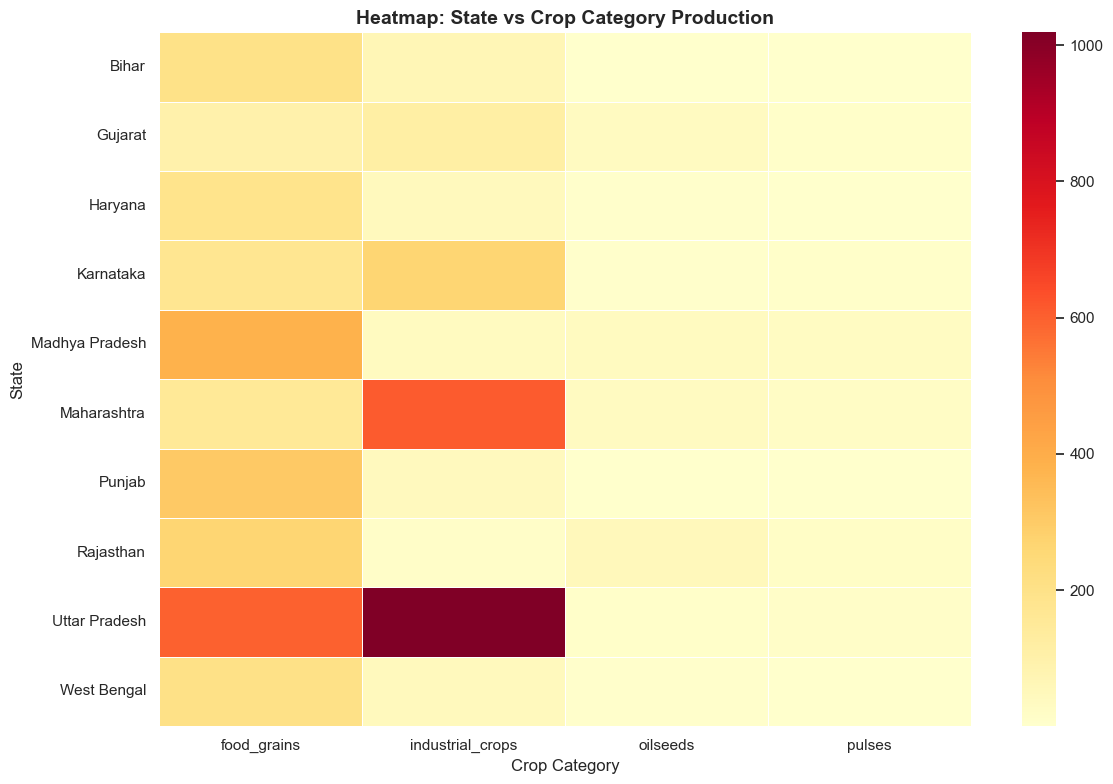

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    pivot_top,
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title('Heatmap: State vs Crop Category Production', fontsize=14, weight='bold')
plt.xlabel('Crop Category')
plt.ylabel('State')

plt.tight_layout()
plt.show()

***Insight on State-wise Crop Production***

This heatmap shows the production volumes across four crop categories—food grains, industrial crops, oilseeds, and pulses—for selected Indian states.

Uttar Pradesh stands out with the highest production in both food grains and industrial crops, indicating its dominance in these categories.
Maharashtra also shows significant industrial crop production, second only to Uttar Pradesh.
Food grains dominate overall production in most states, especially in Madhya Pradesh, Punjab, Rajasthan, and Bihar.
Production of oilseeds and pulses remains comparatively low across all states.
Takeaway

The data highlights the strong specialization of states in food grains and industrial crops, with Uttar Pradesh and Maharashtra leading. There is considerable scope to boost oilseed and pulse production to achieve crop diversification and enhance food security.

### ***State-wise Crop Category Efficiency***

In [ ]:
# Aggregate at state + crop category level
state_cat = (
    df.groupby(["state", "crop_category"], as_index=False)
      .agg(production_mt=("production_mt", "sum"),
           area_mha=("area_mha", "sum"))
)

# Calculate yield safely (avoid division by zero)
state_cat["yield"] = state_cat["production_mt"] / state_cat["area_mha"].replace(0, float("nan"))

# Calculate state totals using transform (avoids merge)
state_cat["Total_Production"] = state_cat.groupby("state")["production_mt"].transform("sum")
state_cat["Total_Area"] = state_cat.groupby("state")["area_mha"].transform("sum")

# Shares (%)
state_cat["Production_Share (%)"] = (state_cat["production_mt"] / state_cat["Total_Production"]) * 100
state_cat["Land_Share (%)"] = (state_cat["area_mha"] / state_cat["Total_Area"]) * 100

# Efficiency gap
state_cat["Efficiency_Gap"] = state_cat["Production_Share (%)"] - state_cat["Land_Share (%)"]

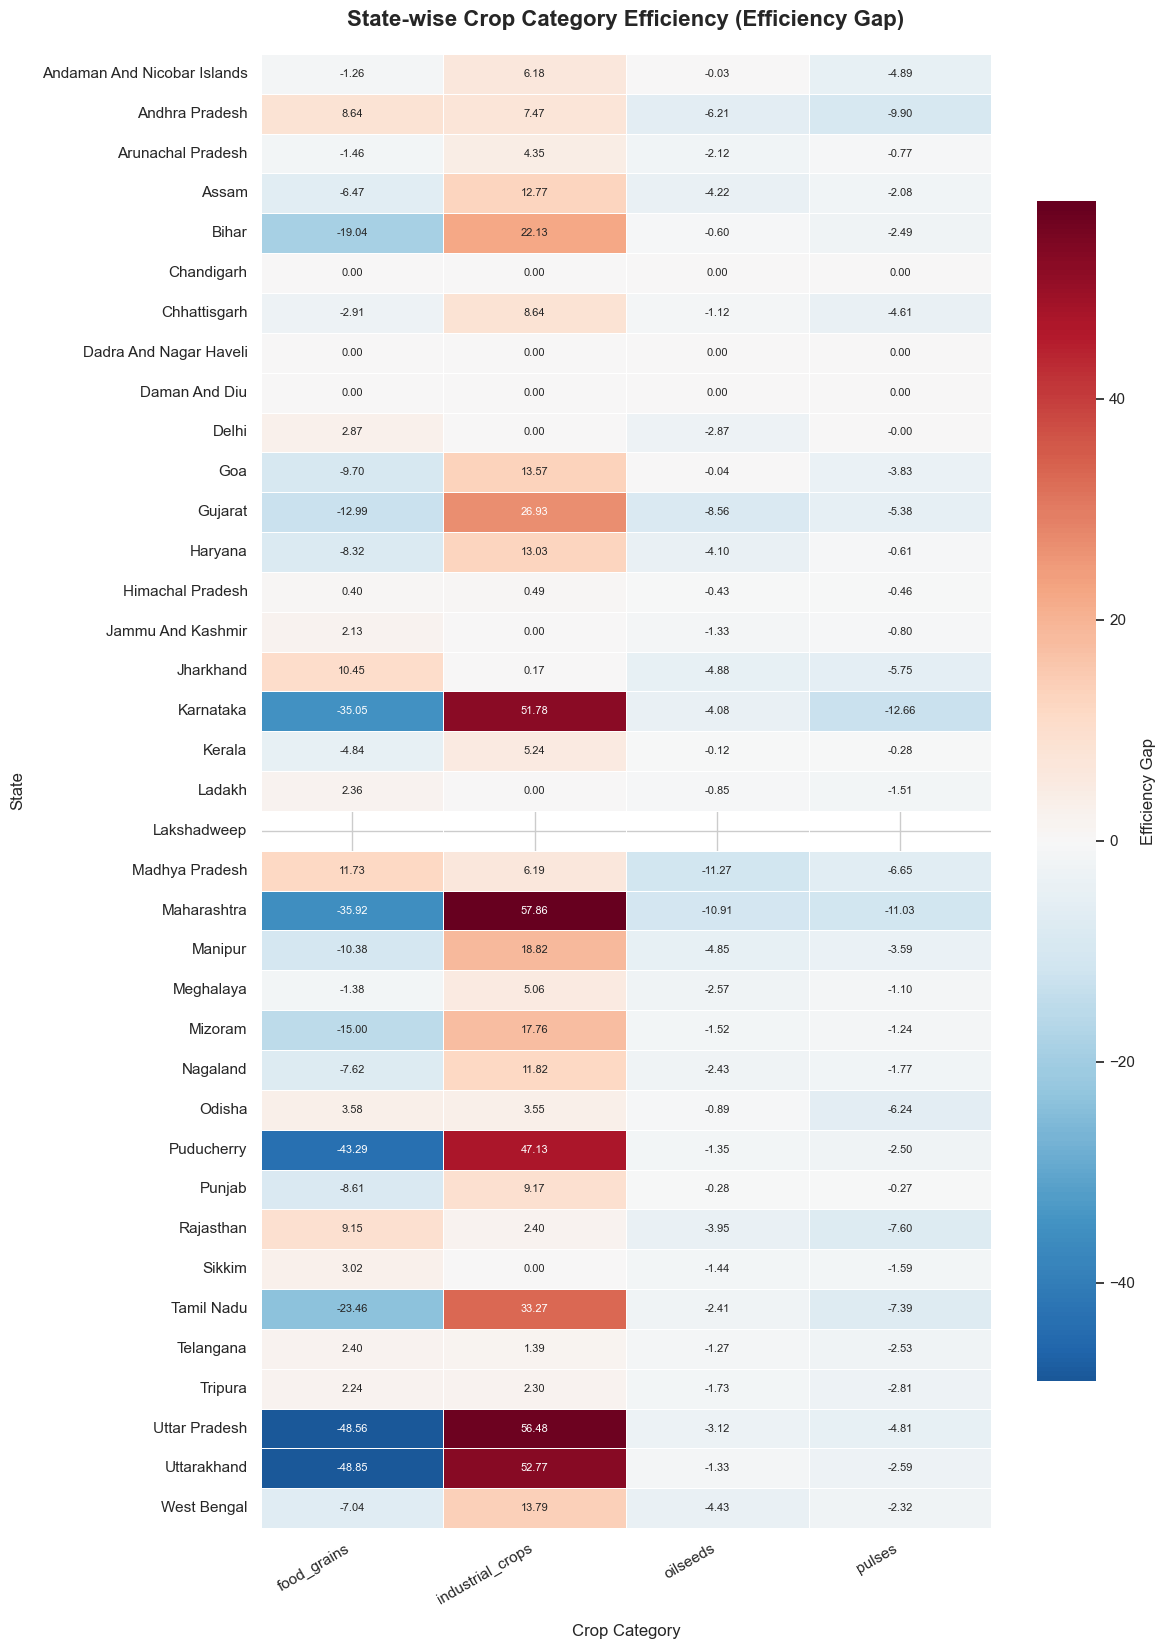

In [ ]:
def plot_efficiency_heatmap(pivot_table):
    # Set global style for better aesthetics
    sns.set_theme(style="whitegrid", font_scale=1.0)

    # Dynamic figure size (keeps readability for many rows)
    fig_height = max(6, len(pivot_table) * 0.45)
    plt.figure(figsize=(12, fig_height))

    # Create heatmap
    ax = sns.heatmap(
        pivot_table,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        linewidths=0.6,
        linecolor="white",
        cbar_kws={
            "shrink": 0.8,
            "label": "Efficiency Gap"
        },
        annot_kws={
            "size": 8
        }
    )

    # Titles and labels
    ax.set_title(
        "State-wise Crop Category Efficiency (Efficiency Gap)",
        fontsize=16,
        pad=20,
        weight="bold"
    )
    ax.set_xlabel("Crop Category", fontsize=12, labelpad=12)
    ax.set_ylabel("State", fontsize=12, labelpad=12)

    # Tick styling
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)

    # Optional: Improve layout spacing
    plt.tight_layout()

    # Optional: Remove spines for cleaner look
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.show()


heatmap_data = state_cat.pivot(
    index="state",
    columns="crop_category",
    values="Efficiency_Gap"
)

# Call the function
plot_efficiency_heatmap(heatmap_data)

***Insight on State-wise Crop Category Efficiency Gap***

This heatmap reveals significant variation in crop efficiency gaps across Indian states and crop categories. Notably, industrial crops show consistently high positive gaps in states like Maharashtra, Karnataka, and Uttar Pradesh, indicating either strong performance or potential data anomalies. In contrast, food grains often display large negative gaps in the same states, pointing to inefficiencies or underperformance in staple crop production.

Oilseeds and pulses generally have smaller negative gaps, suggesting more stable but improvable yields. The wide disparity across states highlights regional differences in agricultural productivity and resource use.